## 지난주 개념 복습!
아래 마크다운을 풀고, 지난주 예습과제를 통해 공부한 Vision Transformer의 특징과 다른 모델들과의 차이점을 간략히 설명해주세요.



- ViT는 이미지를 여러 개의 작은 패치로 나눈 뒤, 이를 하나의 토큰처럼 변환하여 Transformer 구조에 입력하는 방식의 모델이다.


- 각 패치에는 위치 정보를 함께 추가해 이미지 내 순서를 구분하며, Self-Attention을 통해 이미지 전체 영역의 관계를 동시에 학습할 수 있다.


- CNN은 주변 특징을 단계적으로 추출하는 데 강점이 있지만, ViT는 전역적인 정보 관계를 파악하는 데 더 유리하다.


- 다만 CNN이 가진 지역성이나 이동 불변성과 같은 특성이 없기 때문에, 일반적으로 많은 양의 데이터로 사전 학습했을 때 높은 성능을 보인다.

## 파이토치로 구현한 Vision Transformer
이번 복습과제에서는 카사바 잎 질병 데이터셋으로 vision transformer를 학습시키겠습니다.
- 첨부된 드라이브에서 필요한 파일들을 다운받을 수 있습니다.

In [ ]:
!curl https://raw.githubusercontent.com/pytorch/xla/master/contrib/scripts/env-setup.py -o pytorch-xla-env-setup.py
!python pytorch-xla-env-setup.py --version 1.7
!pip install timm
!pip install torch_xla

### 데이터 불러오기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#.zip 파일 unzip
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/Week9/train_images -d /content/drive/MyDrive/Week9/train_images

In [ ]:
#본인 드라이브의 경로에 맞게 수정해주세요!
!unzip /content/drive/MyDrive/Week9/jx_vit_base_p16_224-80ecf9dd.pth.zip -d /content/drive/MyDrive/Week9/

In [ ]:
#파일 경로
DATA_PATH = "/content/drive/MyDrive/Week9/"
TRAIN_PATH = "/content/drive/MyDrive/Week9/train_images"
TEST_PATH = "/content/drive/MyDrive/Week9/test.jpg"
MODEL_PATH = (
    "/content/drive/MyDrive/Week9/jx_vit_base_p16_224-80ecf9dd.pth"
)

### 라이브러리

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

import torch
import torch.nn as nn
import torchvision.transforms as transforms

import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.distributed.xla_multiprocessing as xmp
import torch_xla.distributed.parallel_loader as pl

import timm

import gc
import os
import time
import random
from datetime import datetime

from PIL import Image
from tqdm.notebook import tqdm
from sklearn import model_selection, metrics

/usr/local/lib/python3.12/dist-packages/torch_xla/experimental/gru.py:113: SyntaxWarning: invalid escape sequence '\_'
  * **h_n**: tensor of shape :math:`(D * \text{num\_layers}, H_{out})` or


In [ ]:
os.environ["XLA_USE_BF16"] = "1"
os.environ["XLA_TENSOR_ALLOCATOR_MAXSIZE"] = "100000000"

In [ ]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results

    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(1001)

### 파라미터

In [ ]:
IMG_SIZE = 224  #ViT에 적합한 이미지 크기로 설정해주세요.
BATCH_SIZE = 16
LR = 2e-05
GAMMA = 0.7
N_EPOCHS = 1  #모델 학습을 위해서는 더 많은 에포크가 필요하지만, 파일 크기가 큰 관계로 이번 과제에서는 전 과정을 한 번만 수행하겠습니다.

In [ ]:
# pandas로 csv 파일을 읽은 뒤, 첫 5행을 출력하세요.
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  21397 non-null  object
 1   label     21397 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 334.5+ KB


<Axes: xlabel='label'>

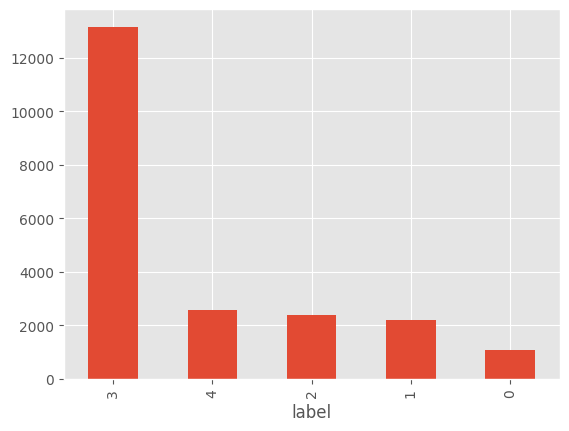

In [ ]:
df.label.value_counts().plot(kind="bar")

In [ ]:
# train과 test를 9:1로 나눠주세요.
# random_state은 자유롭게 지정 가능합니다.
train_df, valid_df = model_selection.train_test_split(
    df, test_size=0.1, random_state=42, stratify=df.label.values
)


In [ ]:
class CassavaDataset(torch.utils.data.Dataset):

    def __init__(self, df, data_path=DATA_PATH, mode="train", transforms=None):
        super().__init__()
        self.df_data = df.values
        self.data_path = data_path
        self.transforms = transforms
        self.mode = mode
        self.data_dir = "train_images" if mode == "train" else "test_images"

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, index):
        img_name, label = self.df_data[index]
        img_path = os.path.join(self.data_path, self.data_dir, img_name)
        img = Image.open(img_path).convert("RGB")

        if self.transforms is not None:
            image = self.transforms(img)

        return image, label

In [ ]:
#데이터 증강
transforms_train = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

transforms_valid = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ]
)

In [ ]:
#사용 가능한 ViT 모델 목록
##우리는 이중 vit_base_patch16_224를 사용합니다!
print("Available Vision Transformer Models: ")
timm.list_models("vit*")

Available Vision Transformer Models: 


['vit_7b_patch16_dinov3',
 'vit_base_mci_224',
 'vit_base_patch8_224',
 'vit_base_patch14_dinov2',
 'vit_base_patch14_reg4_dinov2',
 'vit_base_patch16_18x2_224',
 'vit_base_patch16_224',
 'vit_base_patch16_224_miil',
 'vit_base_patch16_384',
 'vit_base_patch16_clip_224',
 'vit_base_patch16_clip_384',
 'vit_base_patch16_clip_quickgelu_224',
 'vit_base_patch16_dinov3',
 'vit_base_patch16_dinov3_qkvb',
 'vit_base_patch16_gap_224',
 'vit_base_patch16_plus_240',
 'vit_base_patch16_plus_clip_240',
 'vit_base_patch16_reg4_gap_256',
 'vit_base_patch16_rope_224',
 'vit_base_patch16_rope_ape_224',
 'vit_base_patch16_rope_mixed_224',
 'vit_base_patch16_rope_mixed_ape_224',
 'vit_base_patch16_rope_reg1_gap_256',
 'vit_base_patch16_rpn_224',
 'vit_base_patch16_siglip_224',
 'vit_base_patch16_siglip_256',
 'vit_base_patch16_siglip_384',
 'vit_base_patch16_siglip_512',
 'vit_base_patch16_siglip_gap_224',
 'vit_base_patch16_siglip_gap_256',
 'vit_base_patch16_siglip_gap_384',
 'vit_base_patch16_siglip

### 모델 설계
- 클래스 ViTBase16의 각 줄을 설명하는 주석을 달아주세요. (최소 15개)

In [ ]:
class ViTBase16(nn.Module):
    # Vision Transformer 기반 분류 모델 클래스 정의
    def __init__(self, n_classes, pretrained=False):

        # 부모 클래스(nn.Module)의 초기화 함수 호출
        super(ViTBase16, self).__init__()

        # timm 라이브러리에서 ViT Base Patch16 구조 생성
        self.model = timm.create_model("vit_base_patch16_224", pretrained=False)

        # pretrained 옵션이 True인지 확인
        if pretrained:

            # 저장된 사전학습 가중치(weight) 불러오기
            self.model.load_state_dict(torch.load(MODEL_PATH))

        # 기존 분류 헤드를 새로운 Linear layer로 교체
        # 출력 차원을 데이터셋 클래스 수(n_classes)에 맞춤
        self.model.head = nn.Linear(self.model.head.in_features, n_classes)

    # 순전파(forward propagation) 함수 정의
    def forward(self, x):

        # 입력 이미지를 ViT 모델에 통과시킴
        x = self.model(x)

        # 클래스별 예측값(logit) 반환
        return x

    # 한 에포크(epoch) 동안 학습 수행
    def train_one_epoch(self, train_loader, criterion, optimizer, device):

        # 전체 학습 loss 저장 변수
        epoch_loss = 0.0

        # 전체 학습 accuracy 저장 변수
        epoch_accuracy = 0.0

        # 모델을 학습 모드(train mode)로 변경
        self.model.train()

        # train_loader의 배치를 하나씩 반복
        for i, (data, target) in enumerate(train_loader):

            # GPU 사용 시 데이터를 CUDA로 이동
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()

            # TPU 사용 시 XLA 디바이스로 이동
            elif device.type == "xla":

                # 입력 데이터를 float32 타입으로 변환
                data = data.to(device, dtype=torch.float32)

                # 정답 레이블을 int64 타입으로 변환
                target = target.to(device, dtype=torch.int64)

            # 이전 gradient 값 초기화
            optimizer.zero_grad()

            # 모델 예측 수행
            output = self.forward(data)

            # 예측값과 실제값으로 loss 계산
            loss = criterion(output, target)

            # 역전파 수행하여 gradient 계산
            loss.backward()

            # 가장 높은 확률의 클래스를 예측값으로 선택
            accuracy = (output.argmax(dim=1) == target).float().mean()

            # 현재 배치의 loss 누적
            epoch_loss += loss

            # 현재 배치의 accuracy 누적
            epoch_accuracy += accuracy

            # TPU 환경인 경우
            if device.type == "xla":

                # TPU 전용 optimizer step 수행
                xm.optimizer_step(optimizer)

                # 20배치마다 현재 loss 출력
                if i % 20 == 0:
                    xm.master_print(
                        f"\tBATCH {i+1}/{len(train_loader)} - LOSS: {loss}"
                    )

            else:
                # CPU/GPU 환경에서 가중치 업데이트 수행
                optimizer.step()

        # 평균 loss와 평균 accuracy 반환
        return epoch_loss / len(train_loader), epoch_accuracy / len(train_loader)

    # 검증(validation) 수행 함수
    def validate_one_epoch(self, valid_loader, criterion, device):

        # 검증 loss 저장 변수
        valid_loss = 0.0

        # 검증 accuracy 저장 변수
        valid_accuracy = 0.0

        # 모델을 평가 모드(eval mode)로 변경
        self.model.eval()

        # validation 데이터 반복
        for data, target in valid_loader:

            # GPU 사용 시 CUDA로 이동
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()

            # TPU 사용 시 XLA 디바이스로 이동
            elif device.type == "xla":
                data = data.to(device, dtype=torch.float32)
                target = target.to(device, dtype=torch.int64)

            # gradient 계산 비활성화
            with torch.no_grad():

                # 검증 데이터 예측 수행
                output = self.model(data)

                # validation loss 계산
                loss = criterion(output, target)

                # validation accuracy 계산
                accuracy = (output.argmax(dim=1) == target).float().mean()

                # loss 누적
                valid_loss += loss

                # accuracy 누적
                valid_accuracy += accuracy

        # 평균 validation loss와 accuracy 반환
        return valid_loss / len(valid_loader), valid_accuracy / len(valid_loader)

In [ ]:
def fit_tpu(
    model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
):

    valid_loss_min = np.inf

    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        para_train_loader = pl.ParallelLoader(train_loader, [device])

        xm.master_print(f"{'='*50}")
        xm.master_print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(
            para_train_loader.per_device_loader(device), criterion, optimizer, device
        )
        xm.master_print(
            f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n"
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        gc.collect()

        if valid_loader is not None:
            gc.collect()
            para_valid_loader = pl.ParallelLoader(valid_loader, [device])
            xm.master_print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(
                para_valid_loader.per_device_loader(device), criterion, device
            )
            xm.master_print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss)
            valid_accs.append(valid_acc)
            gc.collect()

            if valid_loss <= valid_loss_min and epoch != 1:
                xm.master_print(
                    "Validation loss decreased ({:.4f} --> {:.4f}).  Saving model ...".format(
                        valid_loss_min, valid_loss
                    )
                )

            valid_loss_min = valid_loss

    return {
        "train_loss": train_losses,
        "valid_losses": valid_losses,
        "train_acc": train_accs,
        "valid_acc": valid_accs,
    }

In [ ]:
model = ViTBase16(n_classes=5, pretrained=True)

In [ ]:
def _run():
    train_dataset = CassavaDataset(train_df, transforms=transforms_train)
    valid_dataset = CassavaDataset(valid_df, transforms=transforms_valid)

    train_sampler = torch.utils.data.distributed.DistributedSampler(
        train_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=True,
    )

    valid_sampler = torch.utils.data.distributed.DistributedSampler(
        valid_dataset,
        num_replicas=xm.xrt_world_size(),
        rank=xm.get_ordinal(),
        shuffle=False,
    )

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler,
        drop_last=True,
        num_workers=8,
    )

    valid_loader = torch.utils.data.DataLoader(
        dataset=valid_dataset,
        batch_size=BATCH_SIZE,
        sampler=valid_sampler,
        drop_last=True,
        num_workers=8,
    )

    criterion = nn.CrossEntropyLoss()  #cross entropy loss로 설정.
    device = xm.xla_device()
    model.to(device)

    lr = LR * xm.xrt_world_size()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    xm.master_print(f"INITIALIZING TRAINING ON {xm.xrt_world_size()} TPU CORES")
    start_time = datetime.now()
    xm.master_print(f"Start Time: {start_time}")

    logs = fit_tpu(
        model=model,
        epochs=N_EPOCHS,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        valid_loader=valid_loader,
    )

    xm.master_print(f"Execution time: {datetime.now() - start_time}")

    xm.master_print("Saving Model")
    xm.save(
        model.state_dict(), f'model_5e_{datetime.now().strftime("%Y%m%d-%H%M")}.pth'
    )

In [ ]:
import torch_xla.core.xla_model as xm
import torch_xla.runtime as xr

# Patch compatibility for old code
if not hasattr(xm, "xrt_world_size"):
    xm.xrt_world_size = xr.world_size

if not hasattr(xm, "get_ordinal"):
    xm.get_ordinal = xr.global_ordinal


In [ ]:
# Training 시작
def _mp_fn(rank, flags):
    torch.set_default_tensor_type("torch.FloatTensor")
    a = _run()


# Run
FLAGS = {}
xmp.spawn(_mp_fn, args=(FLAGS,), nprocs=1, start_method="fork")

INITIALIZING TRAINING ON 1 TPU CORES
Start Time: 2025-11-10 12:12:46.094152
EPOCH 1 - TRAINING...


/tmp/ipython-input-2290256067.py:36: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


	BATCH 1/1203 - LOSS: 1.5625
	BATCH 21/1203 - LOSS: 1.140625
	BATCH 41/1203 - LOSS: 1.2109375
	BATCH 61/1203 - LOSS: 1.15625
	BATCH 81/1203 - LOSS: 1.3671875
	BATCH 101/1203 - LOSS: 1.2890625
	BATCH 121/1203 - LOSS: 1.28125
	BATCH 141/1203 - LOSS: 0.796875
	BATCH 161/1203 - LOSS: 1.0703125
	BATCH 181/1203 - LOSS: 0.859375
	BATCH 201/1203 - LOSS: 1.34375
	BATCH 221/1203 - LOSS: 0.91015625
	BATCH 241/1203 - LOSS: 1.0703125
	BATCH 261/1203 - LOSS: 0.9296875
	BATCH 281/1203 - LOSS: 1.2265625
	BATCH 301/1203 - LOSS: 1.109375
	BATCH 321/1203 - LOSS: 0.79296875
	BATCH 341/1203 - LOSS: 0.8359375
	BATCH 361/1203 - LOSS: 1.203125
	BATCH 381/1203 - LOSS: 1.2734375
	BATCH 401/1203 - LOSS: 0.875
	BATCH 421/1203 - LOSS: 1.2109375
	BATCH 441/1203 - LOSS: 1.2578125
	BATCH 461/1203 - LOSS: 1.203125
	BATCH 481/1203 - LOSS: 0.8125
	BATCH 501/1203 - LOSS: 1.1484375
	BATCH 521/1203 - LOSS: 1.1953125
	BATCH 541/1203 - LOSS: 1.109375
	BATCH 561/1203 - LOSS: 0.91015625
	BATCH 581/1203 - LOSS: 1.21875
	BATCH 6